In [1]:
# Install dependencies
!nvidia-smi
!pip install ultralytics torch torchvision --quiet

Sun Mar 30 00:56:27 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   55C    P8             12W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
from google.colab import files
from google.colab import drive
import xml.etree.ElementTree as ET
import os
import random
import torch
from tqdm import tqdm
import zipfile
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:
USE_PARTIAL_DATA = True # Enable partial data training
PARTIAL_DATA_RATIO = 0.6 # Use 60% of the dataset
DRIVE_CACHING = True # Enable Google Drive caching
AUTO_DEVICE = True  # Auto-select GPU/CPU

YOLO_CONFIG_TEMPLATE = """
path: {dataset_path}
train: images/train
val: images/val
names:
{classes}
"""

# Path configurations
DRIVE_ROOT = '/content/drive/MyDrive/YOLO_VOC2012'
LOCAL_WORKSPACE = '/content/voc_workspace'

In [4]:
# Mount Google Drive if caching enabled
if DRIVE_CACHING:
  drive.mount('/content/drive', force_remount=True)
  os.makedirs(f"{DRIVE_ROOT}/processed_data", exist_ok=True)
  os.makedirs(f"{DRIVE_ROOT}/partial_data", exist_ok=True)

Mounted at /content/drive


In [5]:
# Global constants
CLASS_NAMES = [
  'aeroplane', 'bicycle', 'bird', 'boat', 'bottle', 'bus', 'car', 'cat',
  'chair', 'cow', 'diningtable', 'dog', 'horse', 'motorbike', 'person',
  'pottedplant', 'sheep', 'sofa', 'train', 'tvmonitor'
]

# Device configuration
device = 'cuda' if torch.cuda.is_available() and AUTO_DEVICE else 'cpu'

In [6]:
def create_partial_dataset():
  """Create sampled dataset with specified ratio"""
  print(f"Creating partial dataset ({PARTIAL_DATA_RATIO*100}% sampling)...")
  partial_dir = os.path.join(LOCAL_WORKSPACE, "partial_data")

  # Create directory structure
  for split in ['train', 'val']:
    os.makedirs(os.path.join(partial_dir, "images", split), exist_ok=True)
    os.makedirs(os.path.join(partial_dir, "labels", split), exist_ok=True)

  # Helper function for safe symlinking
  def safe_symlink(src, dst):
    try:
      if not os.path.exists(src):
        raise FileNotFoundError(f"Source path does not exist: {src}")
      os.makedirs(os.path.dirname(dst), exist_ok=True)
      if not os.path.exists(dst):
        os.symlink(src, dst)
        # print(f"Created symlink: {dst} -> {src}")
      return True
    except Exception as e:
      print(f"Symlink creation failed: {str(e)}")
      return False

  # Process both splits
  for split in ['train', 'val']:
    src_img_dir = os.path.join(LOCAL_WORKSPACE, "datasets", "images", split)
    all_images = os.listdir(src_img_dir)
    sampled_images = random.sample(all_images, int(len(all_images)*PARTIAL_DATA_RATIO))

    for img_file in sampled_images:
      base_name = os.path.splitext(img_file)[0]

      # Process image
      src_img = os.path.join(src_img_dir, img_file)
      dst_img = os.path.join(partial_dir, "images", split, img_file)
      safe_symlink(src_img, dst_img)

      # Process label
      src_label = os.path.join(LOCAL_WORKSPACE, "datasets", "labels", split, f"{base_name}.txt")
      dst_label = os.path.join(partial_dir, "labels", split, f"{base_name}.txt")
      if os.path.exists(src_label):
        safe_symlink(src_label, dst_label)

  if DRIVE_CACHING:
    !tar -czf {partial_dir}.tar.gz -C {partial_dir} .
    !cp {partial_dir}.tar.gz {DRIVE_ROOT}/partial_data/

In [7]:
def process_raw_data():
  """Convert raw VOC2012 annotations to YOLO format"""
  # Ensure the workspace directory exists
  os.makedirs(LOCAL_WORKSPACE, exist_ok=True)

  # Download the dataset
  voc_tar_path = f"{LOCAL_WORKSPACE}/VOC2012.tar"
  if not os.path.exists(voc_tar_path):
    print("Downloading VOC2012 dataset...")
    !wget -q -O {voc_tar_path} http://host.robots.ox.ac.uk/pascal/VOC/voc2012/VOCtrainval_11-May-2012.tar
    print(f"Downloaded size: {os.path.getsize(voc_tar_path)} bytes")

  # Extract the dataset
  print("Extracting dataset...")
  !tar -xf {voc_tar_path} -C {LOCAL_WORKSPACE} 2>&1 | tee extraction.log
  if "error" in open("extraction.log").read().lower():
    raise RuntimeError("Dataset extraction failed")

  # Validate the extraction results
  required_dirs = [
    "VOCdevkit/VOC2012/Annotations",
    "VOCdevkit/VOC2012/JPEGImages",
    "VOCdevkit/VOC2012/ImageSets/Main"
  ]
  for dir_path in required_dirs:
    if not os.path.exists(os.path.join(LOCAL_WORKSPACE, dir_path)):
      raise FileNotFoundError(f"Missing critical directory: {dir_path}")

  # Create YOLO directory structure (with multi-level directory creation)
  voc_root = os.path.join(LOCAL_WORKSPACE, "VOCdevkit/VOC2012")
  yolo_dir = os.path.join(LOCAL_WORKSPACE, "datasets")

  # Create YOLO directory structure
  for split in ['train', 'val']:
    os.makedirs(os.path.join(yolo_dir, "images", split), exist_ok=True)
    os.makedirs(os.path.join(yolo_dir, "labels", split), exist_ok=True)

  # Load train/val filenames (read from ImageSets/Main)
  def load_split_names(split='train'):
    split_file = os.path.join(voc_root, "ImageSets/Main", f"{split}.txt")
    with open(split_file, 'r') as f:
      return [line.strip() for line in f.readlines()]

  # Parse XML annotation
  def convert_annotation(image_id, split):
    in_xml = os.path.join(voc_root, "Annotations", f"{image_id}.xml")
    out_txt = os.path.join(yolo_dir, "labels", split, f"{image_id}.txt")

    tree = ET.parse(in_xml)
    root = tree.getroot()

    size = root.find('size')
    img_width = int(size.find('width').text)
    img_height = int(size.find('height').text)

    with open(out_txt, 'w') as f:
      for obj in root.iter('object'):
        cls_name = obj.find('name').text
        if cls_name not in CLASS_NAMES:
          continue  # Skip undefined classes
        cls_id = CLASS_NAMES.index(cls_name)

        bbox = obj.find('bndbox')
        xmin = int(bbox.find('xmin').text)
        ymin = int(bbox.find('ymin').text)
        xmax = int(bbox.find('xmax').text)
        ymax = int(bbox.find('ymax').text)

        # Convert to YOLO format (normalized coordinates)
        x_center = (xmin + xmax) / 2 / img_width
        y_center = (ymin + ymax) / 2 / img_height
        width = (xmax - xmin) / img_width
        height = (ymax - ymin) / img_height

        f.write(f"{cls_id} {x_center:.6f} {y_center:.6f} {width:.6f} {height:.6f}\n")

    # Create symbolic link for image file
    src_img = os.path.join(voc_root, "JPEGImages", f"{image_id}.jpg")
    dst_img = os.path.join(yolo_dir, "images", split, f"{image_id}.jpg")
    if os.path.exists(src_img) and not os.path.exists(dst_img):
      os.symlink(src_img, dst_img)

  # Process training and validation sets
  for split in ['train', 'val']:
    image_ids = load_split_names(split)
    print(f"Processing {split} set ({len(image_ids)} images)...")
    for image_id in tqdm(image_ids):
      convert_annotation(image_id, split)

  print("Dataset conversion completed!")

In [8]:
"""Dataset preparation workflow"""
print("\n=== Preparing Dataset ===")

os.makedirs(LOCAL_WORKSPACE, exist_ok=True)

# Check for cached data
if DRIVE_CACHING and os.path.exists(f"{DRIVE_ROOT}/processed_data/.success"):
  print("Attempting to load cached data...")
  !rsync -avh --progress {DRIVE_ROOT}/processed_data/ {LOCAL_WORKSPACE}/datasets/
  if not os.path.exists(f"{LOCAL_WORKSPACE}/datasets/images/train"):
    print("Cached data incomplete, reprocessing...")
    process_raw_data()
else:
  print("Processing raw data...")
  process_raw_data()
  if DRIVE_CACHING:
    print("Archiving processed data...")
    !tar -czvf {LOCAL_WORKSPACE}/processed_data.tar.gz -C {LOCAL_WORKSPACE}/datasets .
    !cp -v {LOCAL_WORKSPACE}/processed_data.tar.gz {DRIVE_ROOT}/processed_data/
    !touch {DRIVE_ROOT}/processed_data/.success

if USE_PARTIAL_DATA:
  print("Creating partial dataset...")
  create_partial_dataset()

required_paths = [
  os.path.join(LOCAL_WORKSPACE, "datasets/images/train"),
  os.path.join(LOCAL_WORKSPACE, "datasets/labels/train")
]
for path in required_paths:
  if not os.path.exists(path):
    raise FileNotFoundError(f"Critical path missing: {path}")
  print(f"Verified existence: {path}")


=== Preparing Dataset ===
Attempting to load cached data...
sending incremental file list
created directory /content/voc_workspace/datasets
./
.success
              0 100%    0.00kB/s    0:00:00 (xfr#1, to-chk=1/3)
processed_data.tar.gz
        779.81K 100%  237.48MB/s    0:00:00 (xfr#2, to-chk=0/3)

sent 780.18K bytes  received 111 bytes  312.11K bytes/sec
total size is 779.81K  speedup is 1.00
Cached data incomplete, reprocessing...
Downloaded size: 1999639040 bytes
Extracting dataset...
Processing train set (5717 images)...


100%|██████████| 5717/5717 [00:01<00:00, 3574.90it/s]


Processing val set (5823 images)...


100%|██████████| 5823/5823 [00:01<00:00, 3576.64it/s]


Dataset conversion completed!
Creating partial dataset...
Creating partial dataset (60.0% sampling)...
Verified existence: /content/voc_workspace/datasets/images/train
Verified existence: /content/voc_workspace/datasets/labels/train


In [9]:
def create_yolo_config(dataset_path, class_names):
  """Generate YOLO config file using template"""
  classes_str = '\n'.join([f'  {i}: {cls}' for i, cls in enumerate(class_names)])
  return YOLO_CONFIG_TEMPLATE.format(dataset_path=dataset_path,
                    classes=classes_str).strip()

def train_model():
  """Main training workflow"""
  print("\n=== Starting Training ===")

  # Select dataset path
  dataset_path = os.path.join(LOCAL_WORKSPACE, "partial_data" if USE_PARTIAL_DATA else "datasets")

  # Create YOLO config
  config_path = os.path.join(dataset_path, "voc_config.yaml")
  config_content = create_yolo_config(dataset_path, CLASS_NAMES)
  with open(config_path, 'w') as f:
    f.write(config_content)

  # Initialize model
  model = YOLO('yolo11n.pt').to(device)

  # Training parameters
  training_params = {
    'data': config_path,
    'epochs': 50 if USE_PARTIAL_DATA else 100,
    'batch': 32 if USE_PARTIAL_DATA else 16,
    'imgsz': 416 if USE_PARTIAL_DATA else 640,
    'device': device,
    'optimizer': 'Adam',
    'lr0': 0.01,
    'amp': True,
    'cache': 'disk' if DRIVE_CACHING else 'ram',
    'project': 'voc2012_train',
    'name': 'exp'
  }

  # Start training
  results = model.train(**training_params)
  print(f"Training completed! Results saved to: {results.save_dir}")

In [10]:
train_model()


=== Starting Training ===


100%|██████████| 5.35M/5.35M [00:00<00:00, 359MB/s]


Ultralytics 8.3.98 🚀 Python-3.11.11 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: task=detect, mode=train, model=yolo11n.pt, data=/content/voc_workspace/partial_data/voc_config.yaml, epochs=50, time=None, patience=100, batch=32, imgsz=416, save=True, save_period=-1, cache=disk, device=cuda, workers=8, project=voc2012_train, name=exp, exist_ok=False, pretrained=True, optimizer=Adam, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_labels=T

100%|██████████| 755k/755k [00:00<00:00, 108MB/s]


Overriding model.yaml nc=80 with nc=20

                   from  n    params  module                                       arguments                     
  0                  -1  1       464  ultralytics.nn.modules.conv.Conv             [3, 16, 3, 2]                 
  1                  -1  1      4672  ultralytics.nn.modules.conv.Conv             [16, 32, 3, 2]                
  2                  -1  1      6640  ultralytics.nn.modules.block.C3k2            [32, 64, 1, False, 0.25]      
  3                  -1  1     36992  ultralytics.nn.modules.conv.Conv             [64, 64, 3, 2]                
  4                  -1  1     26080  ultralytics.nn.modules.block.C3k2            [64, 128, 1, False, 0.25]     
  5                  -1  1    147712  ultralytics.nn.modules.conv.Conv             [128, 128, 3, 2]              
  6                  -1  1     87040  ultralytics.nn.modules.block.C3k2            [128, 128, 1, True]           
  7                  -1  1    295424  ultralytic

...

                   all       3493       9523      0.527      0.423      0.432      0.279

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


      50/50      3.46G      1.179      1.534      1.353          8        416: 100%|██████████| 108/108 [00:33<00:00,  3.22it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 55/55 [00:19<00:00,  2.80it/s]


                   all       3493       9523      0.512      0.437      0.441      0.289

50 epochs completed in 0.804 hours.
Optimizer stripped from voc2012_train/exp/weights/last.pt, 5.4MB
Optimizer stripped from voc2012_train/exp/weights/best.pt, 5.4MB

Validating voc2012_train/exp/weights/best.pt...
Ultralytics 8.3.98 🚀 Python-3.11.11 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLO11n summary (fused): 100 layers, 2,586,052 parameters, 0 gradients, 6.3 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 55/55 [00:24<00:00,  2.25it/s]


                   all       3493       9523      0.511      0.438      0.441      0.289
             aeroplane        216        298      0.652      0.614      0.615       0.45
               bicycle        166        208      0.573      0.548      0.565      0.382
                  bird        220        393      0.455      0.318      0.293      0.181
                  boat        156        310      0.439      0.235      0.247      0.143
                bottle        237        458      0.451       0.21      0.206      0.109
                   bus        134        201      0.729      0.628      0.699      0.571
                   car        336        661      0.577      0.454      0.498      0.332
                   cat        336        383      0.536      0.668      0.621      0.429
                 chair        396        898      0.442      0.219      0.249      0.134
                   cow         89        199       0.32      0.342      0.238      0.149
           diningtabl

In [11]:
# Save results
def zipdir(path, ziph):
  for root, dirs, files in os.walk(path):
    for file in files:
      file_path = os.path.join(root, file)
      ziph.write(file_path, os.path.relpath(file_path, os.path.join(path, '..')))
with zipfile.ZipFile('training_results.zip', 'w', zipfile.ZIP_DEFLATED) as zipf:
  zipdir('voc2012_train/exp/', zipf)
files.download('training_results.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [12]:
# Display training experiment results
def show_exp_results(exp_dir='voc2012_train/exp'):
  """Display result charts and configurations from the experiment directory"""
  import matplotlib.pyplot as plt
  import yaml
  from IPython.display import display, Markdown

  print("\n=== Experiment Results ===")

  try:
    # Display training metrics plot
    results_img = os.path.join(exp_dir, 'results.png')
    if os.path.exists(results_img):
      plt.figure(figsize=(12, 8))
      img = plt.imread(results_img)
      plt.imshow(img)
      plt.axis('off')
      plt.title('Training Metrics')
      plt.show()
    else:
      print("Warning: Results plot not found - results.png")

    # Display confusion matrix
    confusion_img = os.path.join(exp_dir, 'confusion_matrix.png')
    if os.path.exists(confusion_img):
      plt.figure(figsize=(10, 8))
      img = plt.imread(confusion_img)
      plt.imshow(img)
      plt.axis('off')
      plt.title('Confusion Matrix')
      plt.show()
    else:
      print("Warning: Confusion matrix not found - confusion_matrix.png")

    # Display training configuration
    opt_file = os.path.join(exp_dir, 'args.yaml')
    if os.path.exists(opt_file):
      with open(opt_file) as f:
        opts = yaml.safe_load(f)
        display(Markdown("### Training Configuration"))
        print(yaml.dump(opts, allow_unicode=True, sort_keys=False))
    else:
      print("Warning: Config file not found - args.yaml")

    # Show best model info
    best_pt = os.path.join(exp_dir, 'weights/best.pt')
    if os.path.exists(best_pt):
      file_size = os.path.getsize(best_pt) / 1024**2  # MB
      print(f"\nBest model saved at: {best_pt}")
      print(f"Model size: {file_size:.2f} MB")
    else:
      print("Warning: Best model not found - best.pt")

  except Exception as e:
    print(f"Error displaying experiment content: {str(e)}")


=== Experiment Results ===


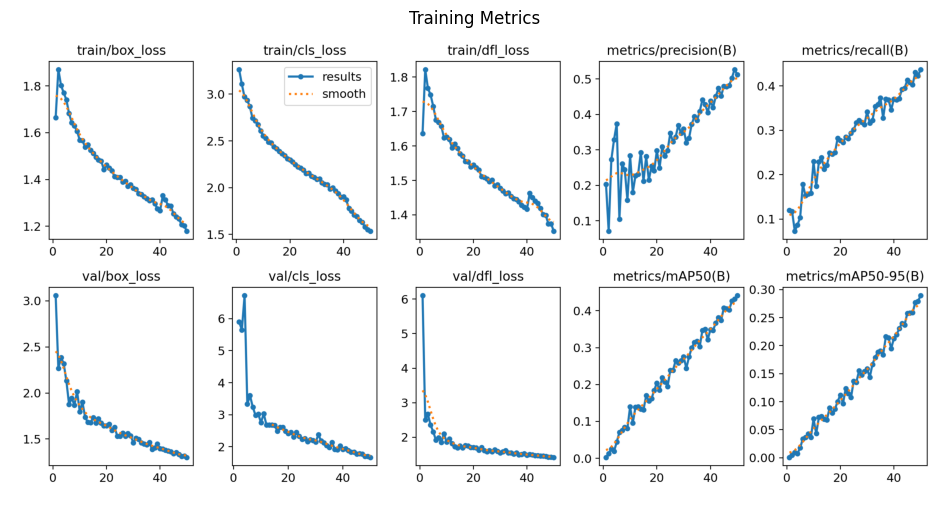

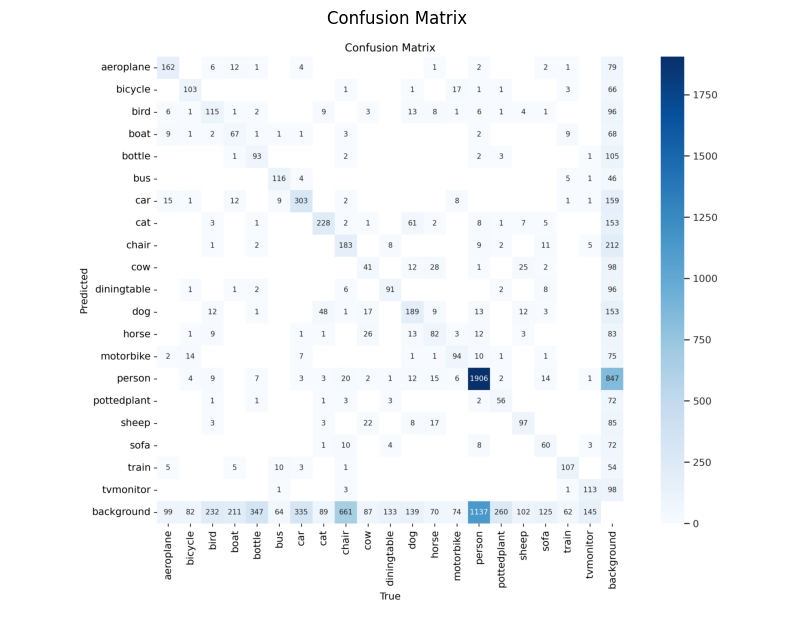

### Training Configuration

task: detect
mode: train
model: yolo11n.pt
data: /content/voc_workspace/partial_data/voc_config.yaml
epochs: 50
time: null
patience: 100
batch: 32
imgsz: 416
save: true
save_period: -1
cache: disk
device: cuda
workers: 8
project: voc2012_train
name: exp
exist_ok: false
pretrained: true
optimizer: Adam
verbose: true
seed: 0
deterministic: true
single_cls: false
rect: false
cos_lr: false
close_mosaic: 10
resume: false
amp: true
fraction: 1.0
profile: false
freeze: null
multi_scale: false
overlap_mask: true
mask_ratio: 4
dropout: 0.0
val: true
split: val
save_json: false
save_hybrid: false
conf: null
iou: 0.7
max_det: 300
half: false
dnn: false
plots: true
source: null
vid_stride: 1
stream_buffer: false
visualize: false
augment: false
agnostic_nms: false
classes: null
retina_masks: false
embed: null
show: false
save_frames: false
save_txt: false
save_conf: false
save_crop: false
show_labels: true
show_conf: true
show_boxes: true
line_width: null
format: torchscript
keras: false
optimize: 

In [13]:
show_exp_results()